# Modeling and Simulation for CIT460 Project

In [42]:
import sqlite3
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [43]:
db_path = r"C:\Users\james\OneDrive\Desktop\CIT460Project\league.db"
conn = sqlite3.connect(db_path)

# Put players into dataframe with match information
df = pd.read_sql_query("""
    SELECT p.*, m.game_duration, m.game_version
    FROM participants p
    JOIN matches_synced m ON p.match_id = m.match_id
""", conn)

conn.close()

Put features into seperate groups (numbers and categories)

In [44]:
numeric_group = ["kills", "deaths", "assists", "gold_earned", "cs", "game_duration"]
categorical_group = ["champion", "position", "spell1", "spell2"]


df_encoded = pd.get_dummies(df, columns=categorical_group, drop_first=True)


y = df_encoded["win"]
X = df_encoded.drop(columns=["id", "match_id", "puuid", "win", "game_version"])

In [45]:
print(X.shape)
print(y.shape)

(22010, 198)
(22010,)


In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Fit the model

In [47]:
model = RandomForestClassifier(random_state=42, n_jobs=-1)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Testing set accuracy:", accuracy)

Testing set accuracy: 0.7714675147660155


Check for overfit

In [48]:
train_pred = model.predict(X_train)
print("Training set accuracy:", accuracy_score(y_train, train_pred))

Training set accuracy: 1.0


Model is overfit, needs investigated. Noted 176 champion options inflate one hot encoding feature count; need more matches (tested with 500 matches, should aim for 10k+). This is due to how one-hot encoding works (1 for the 1 champion picked, 175 0s for the ones not picked)

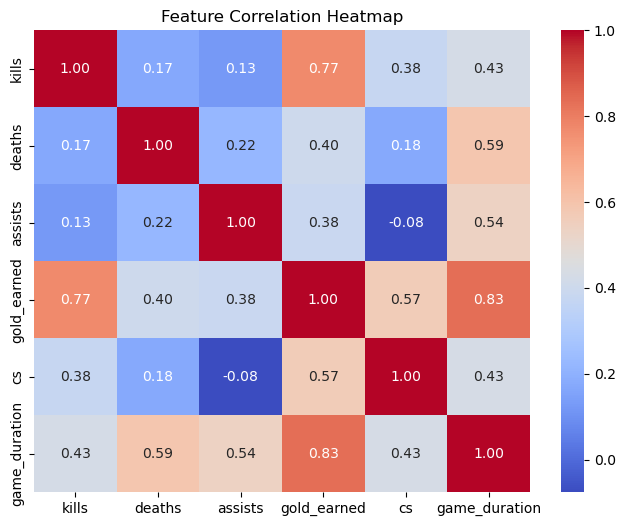

In [49]:
numeric_features = ["kills", "deaths", "assists", "gold_earned", "cs", "game_duration"]

corr = df[numeric_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

Features look fine, RandomForest handles correlation well enough, number of features is misleading though

In [50]:
print("Number of features:", df.shape[1])
df.columns

Number of features: 16


Index(['id', 'match_id', 'puuid', 'champion', 'position', 'win', 'kills',
       'deaths', 'assists', 'gold_earned', 'cs', 'firstBloodKill', 'spell1',
       'spell2', 'game_duration', 'game_version'],
      dtype='object')

In [51]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

total_features = 0
count = 0
for col in df.columns:
    if col in categorical_cols:
        count += 1
        if count <= 2:
            continue
        num_options = df[col].nunique()
        print(f"{col}: {num_options} options")
        total_features += num_options
    else:
        total_features += 1

champion: 172 options
position: 5 options
spell1: 9 options
spell2: 9 options
game_version: 83 options


Ignoring match_id and puuid, theres 200+ options which kind of explains the overfitting also

# Finally getting to the main topic of my project (Simulation)

Simulation is useful for generating live predictions, because it uses historical game data and even past player data for each player to simulate match outcomes, like with the distribution below. Without simulation, my model wouldn't really have enough to go off of, but if I only used pregame data to make the model it wouldn't be very good

In [52]:
champ_stats_by_role = df.groupby(["champion", "position"]).agg({
    "kills": ["mean", "std"],
    "deaths": ["mean", "std"],
    "assists": ["mean", "std"],
    "gold_earned": ["mean", "std"],
    "cs": ["mean", "std"]
}) # not used yet, but this is how simulation will work for live games

Preview of simulation with one match

In [53]:
sample = df.sample(1)
X_match = sample.drop(columns=["id", "match_id", "puuid", "win", "game_version"])

In [54]:
simulations = 1000 # live games will probably use more like 5k for more accuracy, unless this causes enough overhead to where it takes too long
sim_results = []

for _ in range(simulations):
    X_sim = sample.copy()

    
    for col in numeric_group:
        X_sim[col] = X_sim[col] + np.random.normal(0, X_sim[col].values[0]*0.05)

   
    X_sim_encoded = pd.get_dummies(X_sim, columns=categorical_group, drop_first=True)
    X_sim_encoded = X_sim_encoded.reindex(columns=X_train.columns, fill_value=0)

  
    prob = model.predict_proba(X_sim_encoded)[0][1]
    sim_results.append(prob)

sim_results = np.array(sim_results)
print("Simulated win probability mean:", sim_results.mean())

Simulated win probability mean: 0.44843


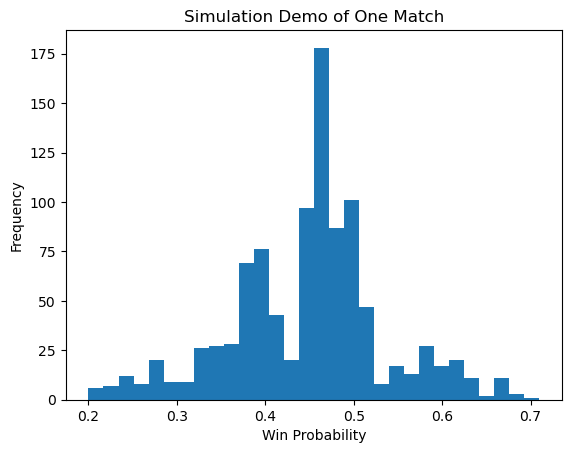

In [55]:
plt.hist(sim_results, bins=30)
plt.xlabel("Win Probability")
plt.ylabel("Frequency")
plt.title("Simulation Demo of One Match")
plt.show()

# TO DO
Change get_rank_puuids() logic to fetch more players
Figure out how to get live data (including historical player data),
Succesfully simulate matches with live data,
Make streamlit work (probably like 30 minutes of work),
Matchup recommendations

Live data seems to be from liveclientdata/allgamedata, which is a local client api. I cannot also get other player's historical game data from this, so it may be useless but still worth investigating. Likely will use some kind of event polling.

Also need to look into basing the model around my own games, possible upsides and downsides to personalized data skewing

# END GOAL

Package model and simulation into one file, which also contains streamlit.

Send file to myself for desktop

Setup file to execute everytime League of Legends is opened on computer

File checks every few seconds for event update

When update detected, streamlit opens browser with statistics and matchup recommendation

Data needs fetched every two weeks for patch update, might need small server for this